<a href="https://www.kaggle.com/code/zhukovoleksiy/ps-s4e1-new-season-eda-ensemble?scriptVersionId=284189356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80"> Introduction</p>

In [1]:
 # Misc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from copy import deepcopy
from functools import partial
import gc
import warnings
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import sklearn classes for model selection, cross validation, and performance evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from category_encoders import OneHotEncoder, OrdinalEncoder, CountEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score, cross_validate

# Import libraries for Hypertuning
import optuna

# Import libraries for gradient boosting
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import NuSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from catboost import CatBoost, CatBoostRegressor, CatBoostClassifier
from catboost import Pool

!pip install cmaes

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/dask/dataframe/_pyarrow_compat.py:23: UserWarning: You are using pyarrow version 11.0.0 which is known to be insecure. See https://www.cve.org/CVERecord?id=CVE-2023-47248 for further details. Please upgrade to pyarrow>=14.0.1 or install pyarrow-hotfix to patch your current version.
  warnings.warn(


  Obtaining dependency information for cmaes from https://files.pythonhosted.org/packages/33/57/f78b7ed51b3536cc80b4322db2cbbb9d1f409736b852eef0493d9fd8474d/cmaes-0.12.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 4.2 MB/s eta 0:00:00


In [2]:
# Seaborn
rc = {
    "axes.facecolor": "#FAEEE9",
    "figure.facecolor": "#FAEEE9",
    "axes.edgecolor": "#000000",
    "grid.color": "#EBEBE7",
    "font.family": "arial",
    "axes.labelcolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "grid.alpha": 0.4
}
sns.set(rc=rc)

# Useful line of code to set the display option so we could see all the columns in pd dataframe
pd.set_option('display.max_columns', None)

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Functions
def print_sl():
    print("=" * 50)
    print()

def show_na(df, column):
    sns.countplot(x='outcome', data=df[df[column].isnull()])
    plt.show() 

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80"> Load Data</p>

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s4e1/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s4e1/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s4e1/sample_submission.csv')

train_orig = pd.read_csv('/kaggle/input/bank-customer-churn-prediction/Churn_Modelling.csv')

train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)
train_orig.drop('RowNumber', axis=1, inplace=True)

print('Data Loaded Succesfully!')
print_sl()

print(f'train shape: {train.shape}')
print(f'are there any null values in train: {train.isnull().any().any()}\n')

print(f'test shape: {test.shape}')
print(f'are there any null values in test: {test.isnull().any().any()}\n')

print(f'train_orig shape: {train_orig.shape}')
print(f'are there any null values in test: {train_orig.isnull().any().any()}\n')

categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

num_cols = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'EstimatedSalary']

target = 'Exited'

train.head()

Data Loaded Succesfully!

train shape: (165034, 13)
are there any null values in train: False

test shape: (110023, 12)
are there any null values in test: False

train_orig shape: (10000, 13)
are there any null values in test: False



,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80">EDA</p>

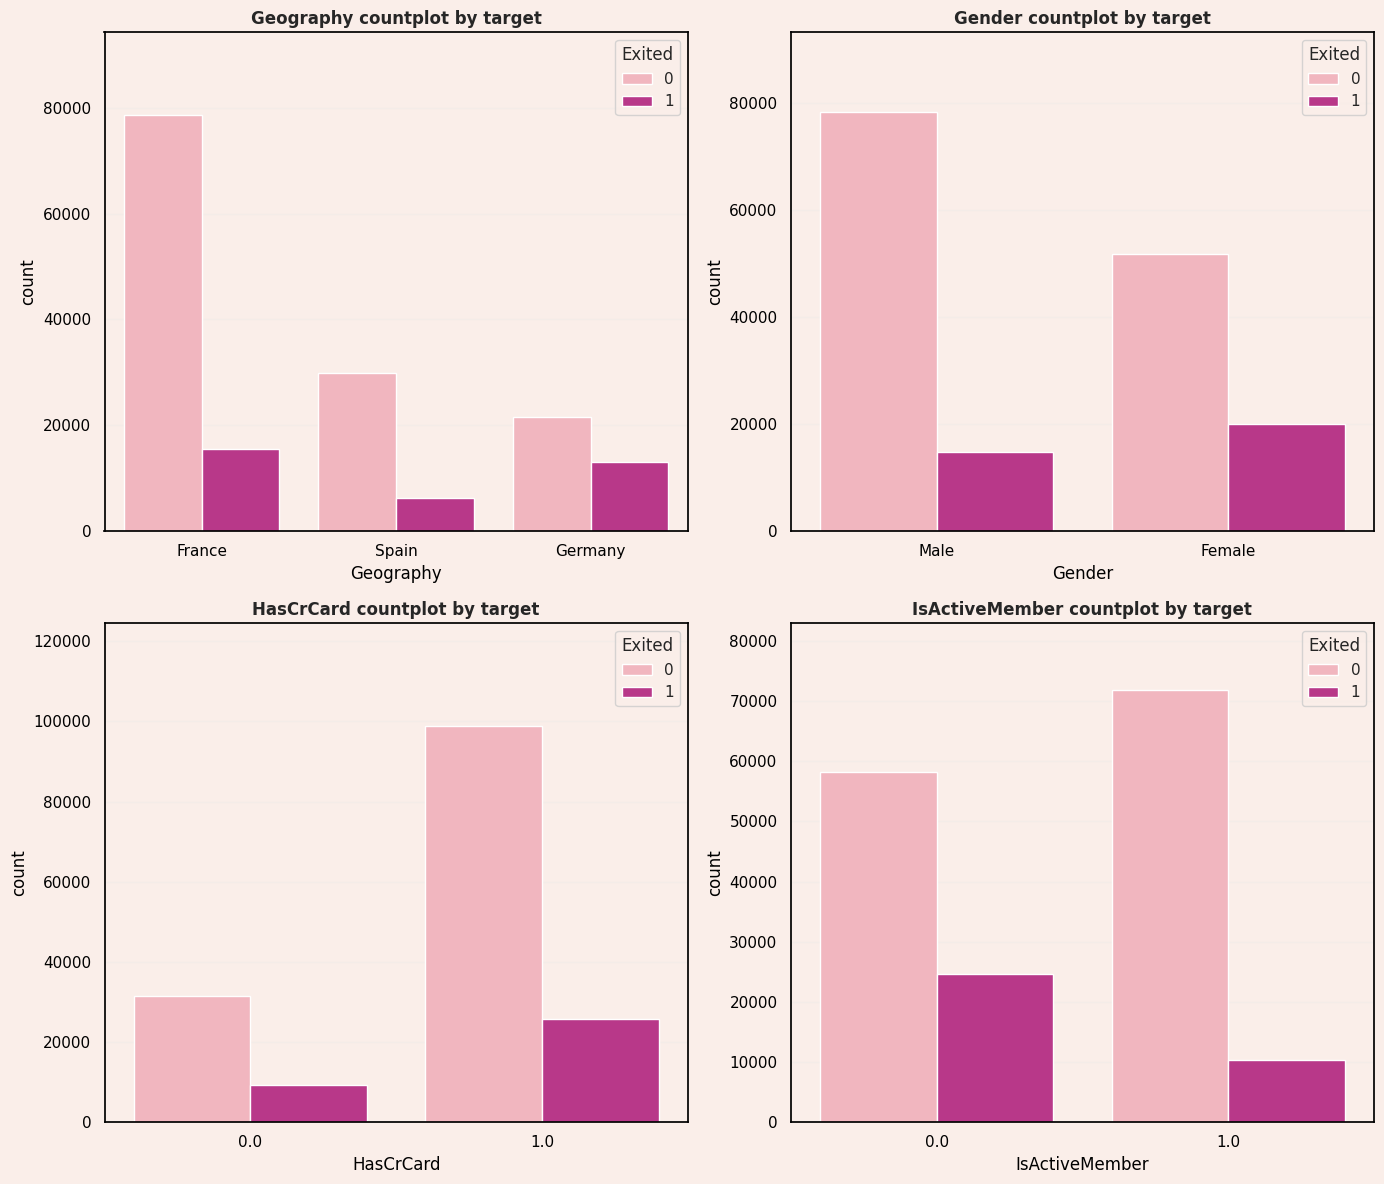

In [4]:
plt.figure(figsize=(14, len(categorical_cols)*3))

for i, col in enumerate(categorical_cols):
    
    plt.subplot(len(categorical_cols)//2 + len(categorical_cols) % 2, 2, i+1)
    sns.countplot(x=col, hue=target, data=train, palette='RdPu')
    plt.title(f"{col} countplot by target", fontweight = 'bold')
    plt.ylim(0, train[col].value_counts().max() + 10)
    
plt.tight_layout()
plt.show()

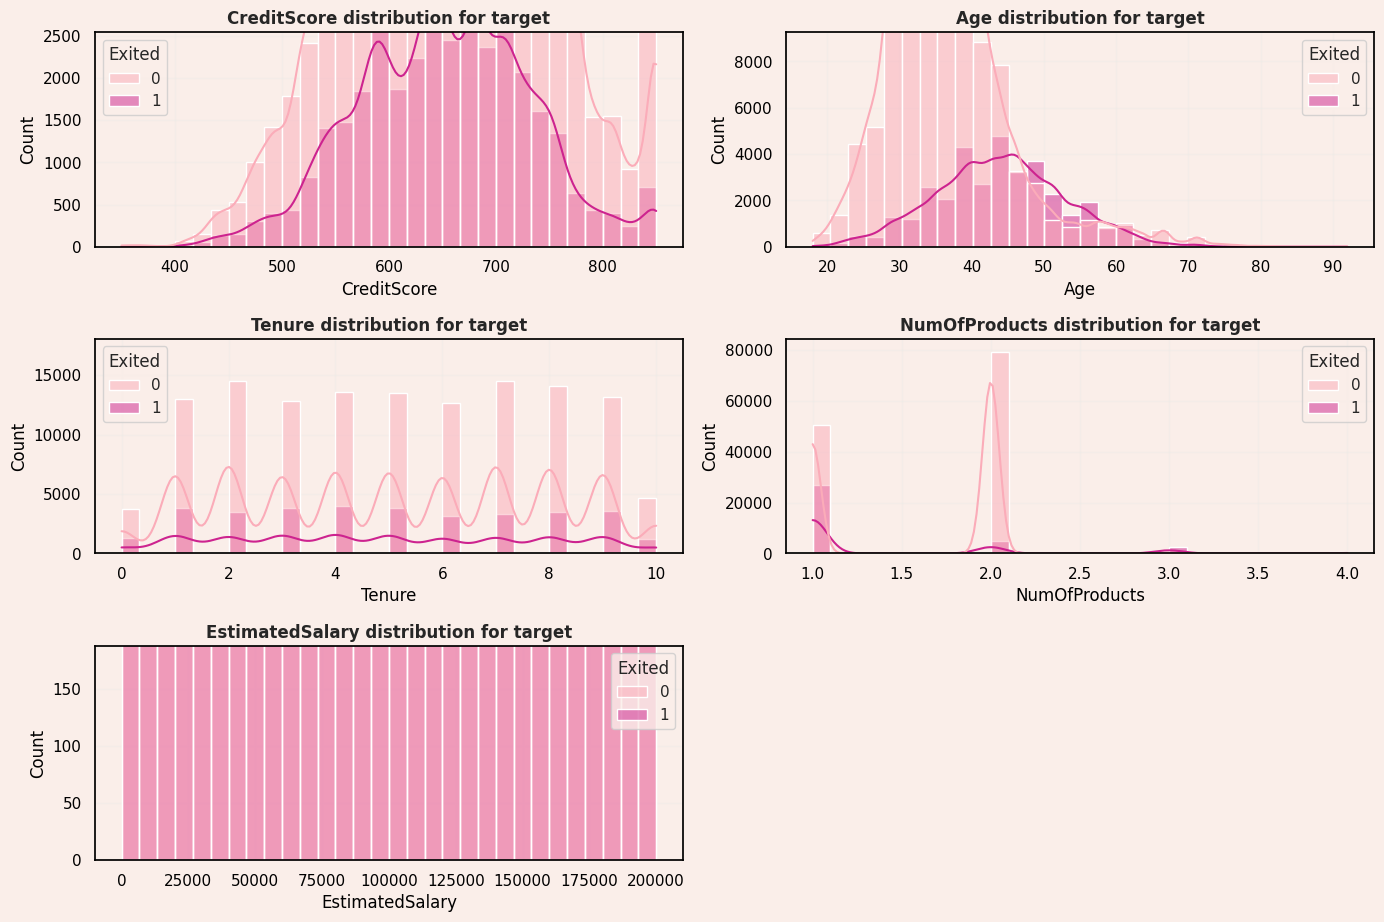

In [5]:
plt.figure(figsize=(14, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Plotting for outcome
    plt.subplot(len(num_cols), 2, i+1)
    sns.histplot(x=col, hue=target, data=train, bins=30, kde=True, palette='RdPu')
    plt.title(f"{col} distribution for target", fontweight="bold")
    plt.ylim(0, train[col].value_counts().max() + 10)
    
plt.tight_layout()
plt.show()

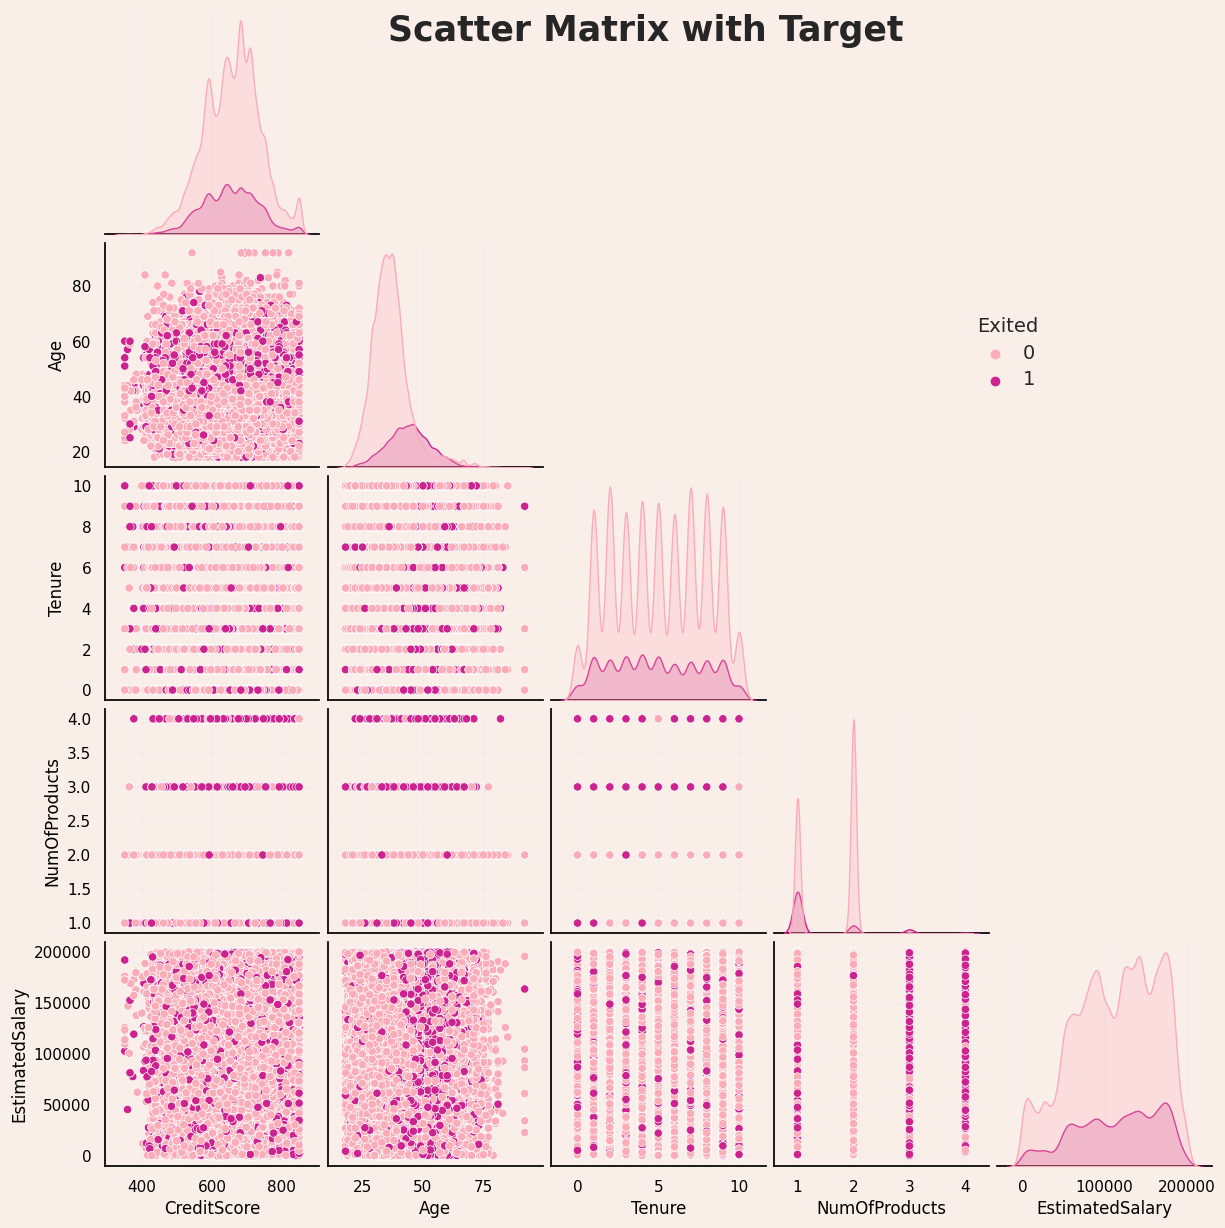

In [6]:
# https://www.kaggle.com/code/yaaangzhou/playground-s3-e22-eda-modeling/notebook
def plot_pair(df_train,num_var,target,plotname):
    '''
    Funtion to make a pairplot:
    df_train: total data
    num_var: a list of numeric variable
    target: target variable
    '''
    g = sns.pairplot(data=df_train, x_vars=num_var, y_vars=num_var, hue=target, corner=True,  palette='RdPu')
    g._legend.set_bbox_to_anchor((0.8, 0.7))
    g._legend.set_title(target)
    g._legend.loc = 'upper left'
    g._legend.get_title().set_fontsize(14)
    for item in g._legend.get_texts():
        item.set_fontsize(14)

    plt.suptitle(plotname, ha='center', fontweight='bold', fontsize=25, y=0.98)
    plt.show()

plot_pair(train, num_cols, target, plotname = 'Scatter Matrix with Target')

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80">Data Cleaning</p>

In [7]:
scale_cols = ['Age','CreditScore', 'Balance','EstimatedSalary']
###
for c in scale_cols:
    min_value = train[c].min()
    max_value = train[c].max()
    train[c+"_scaled"] = (train[c] - min_value) / (max_value - min_value)
    test[c+"_scaled"] = (test[c] - min_value) / (max_value - min_value)
    train_orig[c+"_scaled"] = (train_orig[c] - min_value) / (max_value - min_value)

In [8]:
train.drop(['CustomerId'],axis=1,inplace=True) # 'Surname'
test.drop(['CustomerId'],axis=1,inplace=True) # 'Surname'
train_orig.drop(['CustomerId'], axis=1, inplace=True) # 'Surname'

In [9]:
# transform surname.
label_enc = LabelEncoder()

train["Surname"] = label_enc.fit_transform(train[["Surname"]])
test["Surname"] = label_enc.fit_transform(test[["Surname"]])
train_orig["Surname"] = label_enc.fit_transform(train_orig["Surname"])

train['logarithm_balance'] = np.log1p(train['Balance'])
test['logarithm_balance'] = np.log1p(test['Balance'])
train_orig['logarithm_balance'] = np.log1p(train_orig['Balance'])

train['logarithm_salary'] = np.log1p(train['EstimatedSalary'])
test['logarithm_salary'] = np.log1p(test['EstimatedSalary'])
train_orig['logarithm_salary'] = np.log1p(train_orig['EstimatedSalary'])

In [10]:
# Create total and transform columns
total = pd.concat([train, train_orig])

total['Gender'] = total['Gender'].map({'Male': 1, 'Female': 0})
test['Gender'] = test['Gender'].map({'Male': 1, 'Female': 0})

label_enc = LabelEncoder()

total["Geography"] = label_enc.fit_transform(total[["Geography"]])
test["Geography"] = label_enc.transform(test[["Geography"]])

In [11]:
# https://www.kaggle.com/code/aspillai/bank-churn-catboost-0-8932#Feature-Engineering
def getFeats(df):
    
    df['IsSenior'] = df['Age'].apply(lambda x: 1 if x >= 60 else 0)
    df['IsActive_by_CreditCard'] = df['HasCrCard'] * df['IsActiveMember']
    df['Products_Per_Tenure'] =  df['Tenure'] / df['NumOfProducts']
    df['AgeCat'] = np.round(df.Age/20).astype('int')
    
    return df


total = getFeats(total)
test = getFeats(test)

In [12]:
# Create X_train, X_test and y_train
X_train = total.drop(columns=[target])
y_train = total[target]
X_test = test

print(f'X_train shape: {X_train.shape}')

print(f'X_test shape: {X_test.shape}')

print(f'y_train shape: {y_train.shape}')

del train, test, total
gc.collect();

X_train.head()

X_train shape: (175034, 21)
X_test shape: (110023, 21)
y_train shape: (175034,)


,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Age_scaled,CreditScore_scaled,Balance_scaled,EstimatedSalary_scaled,logarithm_balance,logarithm_salary,IsSenior,IsActive_by_CreditCard,Products_Per_Tenure,AgeCat
0,1924,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97,0.202703,0.636,0.000000,0.907279,0.00000,12.108741,0,0.0,1.5,2
1,1925,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50,0.202703,0.554,0.000000,0.247483,0.00000,10.809819,0,1.0,0.5,2
2,1178,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69,0.297297,0.656,0.000000,0.924364,0.00000,12.127396,0,0.0,5.0,2
3,1299,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88,0.216216,0.462,0.593398,0.422787,11.91092,11.345239,0,1.0,2.0,2
4,467,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83,0.202703,0.732,0.000000,0.075293,0.00000,9.620450,0,1.0,2.5,2


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80">Model Building</p>

Code for hypertuning LGBM:

```python
def objective(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators',500,1500),
        "max_depth":trial.suggest_int('max_depth',5,15),
        "learning_rate" : trial.suggest_float('learning_rate',1e-4, 0.1, log=True),
        "min_child_weight" : trial.suggest_float('min_child_weight', 0.5,4),
        "min_child_samples" : trial.suggest_int('min_child_samples',1,250),
        "subsample" : trial.suggest_float('subsample', 0.2, 1),
        "subsample_freq" : trial.suggest_int('subsample_freq',0,5),
        "colsample_bytree" : trial.suggest_float('colsample_bytree',0.2,1),
        'num_leaves' : trial.suggest_int('num_leaves', 8, 16),
    }
    lgbmopt = lgb.LGBMClassifier(**params,random_state=42,device="gpu")
    cv = cross_val_score(lgbmopt, X_train, y_train, cv = 5, scoring='roc_auc').mean()
    return cv

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)
```

Code for hypertuning XGBoost:

```python
def objective(trial):
    params = {
    'n_estimators' : trial.suggest_int('n_estimators',500,1000),
    'max_depth':  trial.suggest_int('max_depth',3,9),
    'min_child_weight': trial.suggest_float('min_child_weight', 2,4),
    "learning_rate" : trial.suggest_float('learning_rate',1e-4, 0.2),
    'subsample': trial.suggest_float('subsample', 0.2, 1),
    'gamma': trial.suggest_float("gamma", 1e-4, 1.0),
    "colsample_bytree" : trial.suggest_float('colsample_bytree',0.2,1),
    "colsample_bylevel" : trial.suggest_float('colsample_bylevel',0.2,1),
    "colsample_bynode" : trial.suggest_float('colsample_bynode',0.2,1),
    }
    
    xgbopt = xgb.XGBClassifier(**params,random_state=42,tree_method = "gpu_hist",eval_metric= "auc")
    cv = cross_val_score(xgbopt, X_train, y_train, cv = 5,scoring='roc_auc').mean()
    return cv

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)
```

Code for hypertuning CatBoost:

```python
def objective(trial):
    params = {
        'iterations' : trial.suggest_int('iterations',500, 1500),
        "depth":trial.suggest_int('depth',3,10),
        "learning_rate" : trial.suggest_float('learning_rate',1e-4, 0.1, log=True),
        "subsample" : trial.suggest_float('subsample', 0.2, 1),
#         'max_leaves' : trial.suggest_int('max_leaves', 5, 30),
    }
    lgbmopt = CatBoostClassifier(**params,random_state=42, verbose=300)
    cv = cross_val_score(lgbmopt, X_train, y_train, cv = 5, scoring='roc_auc').mean()
    return cv

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
```

In [13]:
class Splitter:
    def __init__(self, kfold=True, n_splits=5):
        self.n_splits = n_splits
        self.kfold = kfold

    def split_data(self, X, y, random_state_list):
        if self.kfold == 'skf':
            for random_state in random_state_list:
                kf = StratifiedKFold(n_splits=self.n_splits, random_state=random_state, shuffle=True)
                for train_index, val_index in kf.split(X, y):
                    if type(X) is np.ndarray:
                        X_train, X_val = X[train_index], X[val_index]
                        y_train, y_val = y[train_index], y[val_index]
                    else:
                        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
                        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
                    yield X_train, X_val, y_train, y_val
        else:
            raise ValueError(f"Invalid kfold: Must be True")

In [14]:
# Weights for class disbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

class_weight_0 = 1.0
class_weight_1 = 1.0 / scale_pos_weight
class_weights_lgb = {0: class_weight_0, 1: class_weight_1}

In [15]:
#

class Classifier:
    def __init__(self, n_estimators=100, device="cpu", random_state=42):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.models = self.get_models()
        self.models_name = list(self.get_models().keys())
        self.len_models = len(self.models)
        
    def get_models(self):
        
        xgb_test0 = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.1,
            'max_depth': 4,
            'subsample': 0.8,
            'colsample_bytree': 0.1,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'objective': 'binary:logistic',
            'tree_method': 'hist',
            'verbosity': 0,
            'random_state': self.random_state,
#             'class_weight':class_weights_dict,
        }
        
        xgb_test1 = {
            'n_estimators': 1500,
            'learning_rate': 0.08901459197907591,
            'booster': 'gbtree',
            'lambda': 8.550251116462702,
            'alpha': 6.92130114930949,
            'eta': 0.7719873740829137,
            'grow_policy': 'lossguide',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            'verbosity': 0,
            'random_state': self.random_state,
            #'scale_pos_weight': scale_pos_weight,
        }
        
        xgb_test2 = {
            'n_estimators': 550,
            'learning_rate': 0.014551680348136895,
            'booster': 'gbtree',
            'lambda': 0.028738149876528587,
            'alpha': 0.014056635017117198,
            'subsample': 0.538653498449084,
            'colsample_bytree': 0.518050828371974, 
            'max_depth': 4, 'min_child_weight': 4,
            'eta': 0.6953619445477833,
            'gamma': 0.9036568111424781,
            'grow_policy': 'lossguide',
            'n_jobs': -1,
            'objective': 'binary:logistic',
            'verbosity': 0,
            'random_state': self.random_state,
            'scale_pos_weight': scale_pos_weight,
        }
        
        xgb_test3 = {
            'n_estimators': 2048,
            'max_depth': 9,
            'learning_rate': 0.045,
            'booster': 'gbtree',
            'subsample': 0.75,
            'colsample_bytree': 0.30,
            'reg_lambda': 1.00,
            'reg_alpha': 0.80,
            'gamma': 0.80,
            'random_state': self.random_state,
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'scale_pos_weight': scale_pos_weight,
        }
        
        xgb_optuna0 = {
            'max_depth': 6,
            'min_child_weight': 2.7526603493948096,
            'learning_rate': 0.015273686530995825,
            'subsample': 0.7109136660293711,
            'gamma': 0.2939927860245192,
            'colsample_bytree': 0.5015735880252528,
            'colsample_bylevel': 0.6877145513802184,
            'colsample_bynode': 0.9449955113410351,
            'random_state': self.random_state,
            'eval_metric': 'auc',
            'scale_pos_weight': scale_pos_weight,
        }
        
        xgb_optuna1 = {
            'n_estimators': 826,
            'max_depth': 7,
            'min_child_weight': 3.847933763609654,
            'learning_rate': 0.02776207189015504,
            'subsample': 0.9483643653132423,
            'gamma': 0.28068683227514724,
            'colsample_bytree': 0.5016925932023183,
            'colsample_bylevel': 0.9393942254550443,
            'colsample_bynode': 0.8472436333890129,
            'random_state': self.random_state,
            'scale_pos_weight': scale_pos_weight,
        }
        
        lgb_test0 = {
            'n_estimators': self.n_estimators,
            'max_depth': 5,
            'learning_rate': 0.015,
            'subsample': 0.50,
            'colsample_bytree': 0.1,
            'reg_alpha': 0.07608657669988828,
            'reg_lambda': 0.2255036530113883,
            'objective': 'binary',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state,
        }
        
        # https://www.kaggle.com/code/iqmansingh/bank-churn-kfold-lgbm-cat-xgb-ensemble/notebook#4.3
        lgb_optuna0 = {
            'max_depth': 41,
            'learning_rate': 0.03432850637422446,
            'min_child_weight': 2.9603503357916763,
            'min_child_samples': 30,
            'subsample': 0.8782988886358021,
            'subsample_freq': 3,
            'colsample_bytree': 0.501275718332705,
            'num_leaves': 25,
            'device': self.device,
            'random_state': self.random_state,
        }
        
        lgb_optuna1 = {
            'n_estimators': 919,
            'max_depth': 12,
            'learning_rate': 0.05386409348876362,
            'min_child_weight': 2.9505407539009907,
            'min_child_samples': 231,
            'subsample': 0.9720314303682901,
            'subsample_freq': 1,
            'colsample_bytree': 0.4204259126112776,
            'num_leaves': 16
        }
        
        cat_optuna1 = {
            'iterations': 1485,
            'depth': 4,
            'learning_rate': 0.05734653878297591,
            'subsample': 0.7557007193665213,
            'random_state': self.random_state,
        }

        models = {
            "xgbt0": xgb.XGBClassifier(**xgb_test0),
            #"xgbt1": xgb.XGBClassifier(**xgb_test1),
            #"xgbt2": xgb.XGBClassifier(**xgb_test2),
            #"xgbt3": xgb.XGBClassifier(**xgb_test3),
            "xgbo0": xgb.XGBClassifier(**xgb_optuna0),
            "xgbo1": xgb.XGBClassifier(**xgb_optuna1),
            
            #"lgbt0": lgb.LGBMClassifier(**lgb_test0),
            "lgbo0": lgb.LGBMClassifier(**lgb_optuna0),
            "lgbo1": lgb.LGBMClassifier(**lgb_optuna1),
            
            "cato1": CatBoostClassifier(**cat_optuna1),
            
            
            #'rf': RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=self.random_state),
        }
        return models

In [16]:
class OptunaWeights:
    def __init__(self, random_state, n_trials=100):
        self.study = None
        self.weights = None
        self.random_state = random_state
        self.n_trials = n_trials

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 1e-15, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the score for the weighted prediction
        score = roc_auc_score(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        pruner = optuna.pruners.HyperbandPruner()
        self.study = optuna.create_study(sampler=sampler, pruner=pruner, study_name="OptunaWeights", direction='maximize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=self.n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds):
        self.fit(y_true, y_preds)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights

In [17]:
#--------------------# Config #--------------------#
kfold = 'skf'
n_splits = 5
n_reapts = 1
random_state = 42
random_state_list =[42]
n_estimators = 999
device = 'cpu'
early_stopping_rounds = 500
verbose = False

In [18]:
%%time

# Fix seed
random.seed(random_state)
random_state_list = random.sample(range(9999), n_reapts)
#random_state_list = [42]

# Initialize an array for storing test predictions
classifier = Classifier(n_estimators, device, random_state)
test_predss = np.zeros((X_test.shape[0]))
oof_predss = np.zeros((X_train.shape[0], n_reapts))

# Store scores and weights
ensemble_score = []
weights = []

# Predictions and models
oof_each_predss = []
oof_each_preds = np.zeros((X_train.shape[0], classifier.len_models))
test_each_predss = []
test_each_preds = np.zeros((X_test.shape[0], classifier.len_models))
trained_models = {'xgb':[],}
score_dict = dict(zip(classifier.models_name, [[] for _ in range(classifier.len_models)]))

# Loop over KFold splits
splitter = Splitter(kfold=kfold, n_splits=n_splits)
for i, (X_train_, X_val, y_train_, y_val) in enumerate(splitter.split_data(X_train, y_train, random_state_list=random_state_list)):
    n = i % n_splits
    m = i // n_splits
            
    # Get a set of classifier models
    classifier = Classifier(n_estimators, device, random_state_list[m])
    models = classifier.models
    
    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []
    
    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if ('xgb' in name) or ('lgb' in name) or ('cat' in name):
            if 'xgb' in name:
                model.fit(
                    X_train_, y_train_, 
                    eval_set=[(X_val, y_val)],
                    early_stopping_rounds=early_stopping_rounds, verbose=verbose)
            elif 'lgb' in name:
                model.fit(
                    X_train_, y_train_, 
                    eval_set=[(X_val, y_val)],
                    early_stopping_rounds=early_stopping_rounds, verbose=verbose)
            elif 'cat' in name:
                model.fit(
                    Pool(X_train_, y_train_), 
                    eval_set=Pool(X_val, y_val),
                    early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        else:
            model.fit(X_train_, y_train_)
            
        if name in trained_models.keys():
            trained_models[f'{name}'].append(deepcopy(model))
        
        test_pred = model.predict_proba(X_test)[:, 1]
        y_val_pred = model.predict_proba(X_val)[:, 1]
        
        # Calculate recall and precision scores
        y_val_pred_binary = (y_val_pred > 0.5).astype(int)
        recall = recall_score(y_val, y_val_pred_binary)
        precision = precision_score(y_val, y_val_pred_binary)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] Recall score: {recall:.5f}')
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] Precision score: {precision:.5f}')

        score = roc_auc_score(y_val, y_val_pred)
        score_dict[name].append(score)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] ROC score: {score:.5f}')
        print('-'*50)
        
        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
    
    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state_list[m])
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)
    
    score_ = roc_auc_score(y_val, y_val_pred)
    print(f'--> Ensemble [FOLD-{n} SEED-{random_state_list[m]}] ROC score {score_:.5f}')
    print_sl()
    ensemble_score.append(score_)
    weights.append(optweights.weights)
    
    # Predict to X_test by the best ensemble weights
    test_predss += optweights.predict(test_preds) / (n_splits * len(random_state_list))
    oof_predss[X_val.index, m] += optweights.predict(oof_preds)
    oof_each_preds[X_val.index] = np.stack(oof_preds).T
    test_each_preds += np.array(test_preds).T / n_splits
    
    if n == (n_splits - 1):
        oof_each_predss.append(oof_each_preds)
        oof_each_preds = np.zeros((X_train.shape[0], classifier.len_models))
        test_each_predss.append(test_each_preds)
        test_each_preds = np.zeros((X_test.shape[0], classifier.len_models))
    
    gc.collect()
    
oof_each_predss = np.mean(np.array(oof_each_predss), axis=0)
test_each_predss = np.mean(np.array(test_each_predss), axis=0)
oof_each_predss = np.concatenate([oof_each_predss, np.mean(oof_predss, axis=1).reshape(-1, 1)], axis=1)
test_each_predss = np.concatenate([test_each_predss, test_predss.reshape(-1, 1)], axis=1)

xgbt0 [FOLD-0 SEED-1824] Recall score: 0.54566
xgbt0 [FOLD-0 SEED-1824] Precision score: 0.75567
xgbt0 [FOLD-0 SEED-1824] ROC score: 0.88870
--------------------------------------------------
xgbo0 [FOLD-0 SEED-1824] Recall score: 0.78379
xgbo0 [FOLD-0 SEED-1824] Precision score: 0.52760
xgbo0 [FOLD-0 SEED-1824] ROC score: 0.88150
--------------------------------------------------
xgbo1 [FOLD-0 SEED-1824] Recall score: 0.77310
xgbo1 [FOLD-0 SEED-1824] Precision score: 0.55513
xgbo1 [FOLD-0 SEED-1824] ROC score: 0.88949
--------------------------------------------------
lgbo0 [FOLD-0 SEED-1824] Recall score: 0.50589
lgbo0 [FOLD-0 SEED-1824] Precision score: 0.77284
lgbo0 [FOLD-0 SEED-1824] ROC score: 0.88621
--------------------------------------------------
lgbo1 [FOLD-0 SEED-1824] Recall score: 0.55311
lgbo1 [FOLD-0 SEED-1824] Precision score: 0.75802
lgbo1 [FOLD-0 SEED-1824] ROC score: 0.89097
--------------------------------------------------
cato1 [FOLD-0 SEED-1824] Recall score: 0

In [19]:
# Calculate the mean score of the ensemble
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Mean Optuna Ensemble {mean_score:.5f} ± {std_score:.5f} \n')

print('--- Optuna Weights---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name}: {mean_weight:.5f} ± {std_weight:.5f}')

Mean Optuna Ensemble 0.89172 ± 0.00088 

--- Optuna Weights---
xgbt0: 0.50182 ± 0.18090
xgbo0: 0.06382 ± 0.06112
xgbo1: 0.44569 ± 0.14138
lgbo0: 0.04332 ± 0.03575
lgbo1: 0.84148 ± 0.12182
cato1: 0.80843 ± 0.09196


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#0B6F80; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #0B6F80">Submission</p>

In [20]:
sample_submission[target] = test_predss
sample_submission.to_csv(f'submission.csv', index=False)
sample_submission

,id,Exited
0,165034,0.059277
1,165035,0.848295
2,165036,0.037394
3,165037,0.378292
4,165038,0.386472
...,...,...
110018,275052,0.053502
110019,275053,0.202634
110020,275054,0.035434
110021,275055,0.177887
